# Test the definition of a 3AFC linear ballistic accumulator model

In [1]:
import os
from pathlib import Path
import math
import numpy as np
from scipy import stats
from scipy import integrate
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import aesara
import aesara.tensor as at
from devreact import figures

figures.set_style()

## Define response probabilities under the model

In [2]:
def normpdf(x):
    return (1 / pm.math.sqrt(2 * math.pi)) * pm.math.exp(-(x ** 2) / 2)


def normcdf(x):
    return (1 / 2) * (1 + pm.math.erf(x / pm.math.sqrt(2)))


def tpdf(t, A, b, v, s):
    """Probability distribution function over time."""
    g = (b - A - t * v) / (t * s)
    h = (b - t * v) / (t * s)
    f = (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h)) / A
    return f


def tcdf(t, A, b, v, s):
    """Cumulative distribution function over time."""
    e1 = ((b - A - t * v) / A) * normcdf((b - A - t * v) / (t * s))
    e2 = ((b - t * v) / A) * normcdf((b - t * v) / (t * s))
    e3 = ((t * s) / A) * normpdf((b - A - t * v) / (t * s))
    e4 = ((t * s) / A) * normpdf((b - t * v) / (t * s))
    F = 1 + e1 - e2 + e3 - e4
    return F

In [3]:
def pdf(response_data, s, τ, A, b, v1, v2, v3):
    """Calculate probability density function for 3AFC using Aesara."""
    i = response_data[:, 0]
    t = response_data[:, 1] - τ

    # PDF for each accumulator
    p1 = tpdf(t, A, b, v1, s)
    p2 = tpdf(t, A, b, v2, s)
    p3 = tpdf(t, A, b, v3, s)

    # probability of having not hit threshold by now
    n1 = 1 - tcdf(t, A, b, v1, s)
    n2 = 1 - tcdf(t, A, b, v2, s)
    n3 = 1 - tcdf(t, A, b, v3, s)

    # conditional probability of each accumulator hitting threshold now
    c1 = p1 * n2 * n3
    c2 = p2 * n1 * n3
    c3 = p3 * n1 * n2

    # calculate probability of this response and rt
    p = at.switch(at.eq(i, 1), c1, at.switch(at.eq(i, 2), c2, c3))
    return p


def function_pdf():
    """Generate an Aesara function to evaluate the PDF."""
    # time and response vary by trial
    r = at.dmatrix('r')

    # parameters are fixed over trial
    s = at.dscalar('s')
    τ = at.dscalar('τ')
    A = at.dscalar('A')
    b = at.dscalar('b')
    v1 = at.dscalar('v1')
    v2 = at.dscalar('v2')
    v3 = at.dscalar('v3')
    
    p = pdf(r, s, τ, A, b, v1, v2, v3)
    f = aesara.function([r, s, τ, A, b, v1, v2, v3], p)
    return f


def logp(response_data, s, τ, A, b, v1, v2, v3):
    """Calculate log probability using Aesara."""
    p = pdf(response_data, s, τ, A, b, v1, v2, v3)
    ll = pm.math.sum(pm.math.log(p))
    return ll

## Define random sampling

In [4]:
def drift_rates(v, s, nt, rng):
    """Generate random drift rates."""
    # sample drift rates with constraint that, on each trial,
    # at least one accumulator must be positive
    nv = len(v)
    d = np.zeros((nt, nv))
    valid = False
    isvalid = np.zeros(nt, dtype=bool)
    while not valid:
        # generate random accumulator drift rates
        c = np.zeros((nt, nv))
        for i in range(nv):
            c[:, i] = rng.normal(loc=v[i], scale=s, size=nt)
        valid_c = c[np.any(c > 0, axis=1), :]
        
        # replace invalid trials
        n = np.count_nonzero(~isvalid)
        m = valid_c.shape[0]
        k = n if n <= m else m
        replace_ind = np.where(~isvalid)[0]
        d[replace_ind[:k], :] = valid_c[:k, :]
        
        # check if all valid
        isvalid = np.any(d > 0, axis=1)
        valid = np.all(isvalid)
    d[d <= 0] = np.nan
    return d

In [5]:
def random(s, τ, A, b, v1, v2, v3, rng, size=None):
    """Randomly sample correct and incorrect response times."""
    if size is None:
        size = (1, 2)
        
    # sample start point and drift on each trial
    k = rng.uniform(0, A, size=(size[0], 3))
    d = drift_rates([v1, v2, v3], s, size[0], rng)
    t = τ + ((b - k) / d)
    
    # score responses (0 is correct, 1 or 2 is incorrect)
    x = np.zeros((d.shape[0], 2))
    x[:, 0] = np.nanargmin(t, axis=1) + 1
    
    # time first accumulator finished
    x[:, 1] = np.nanmin(t, axis=1)
    return x

## Generate data

In [6]:
rng = np.random.default_rng()
nt = 10000
s = 1
τ = 0.5
A = 4
b = 5
v1 = 3
v2 = 1.5
v3 = 1.5
response = random(s, τ, A, b, v1, v2, v3, rng, size=(nt, 2))

## Evaluate PDF

In [7]:
# set times and responses to evaluate
n = 100  # number of times
m = 3  # number of choices
max_time = 4
t = np.tile(np.linspace(0, max_time, n), m)
r = np.repeat(range(1, m + 1), n).astype('int32')
f = function_pdf()
sweep = pd.DataFrame(
    {
        'response': r,
        'response_time': t,
        'pdf': np.zeros(n * m),
    }
)
rmat = sweep[['response', 'response_time']].to_numpy().astype('float64')
sweep['pdf'] = f(rmat, s, τ, A, b, v1, v2, v3)

In [8]:
subs = sweep.query('response == 1')
integrate.trapz(subs['pdf'], subs['response_time'])

0.6444542591447364

In [9]:
subs = sweep.query('response == 2')
integrate.trapz(subs['pdf'], subs['response_time'])

0.1770062813714968

In [10]:
subs = sweep.query('response == 3')
integrate.trapz(subs['pdf'], subs['response_time'])

0.1770062813714968

In [11]:
integrate.trapz(sweep['pdf'], sweep['response_time'])

0.9953937417127787

## Compare generated data to PDF

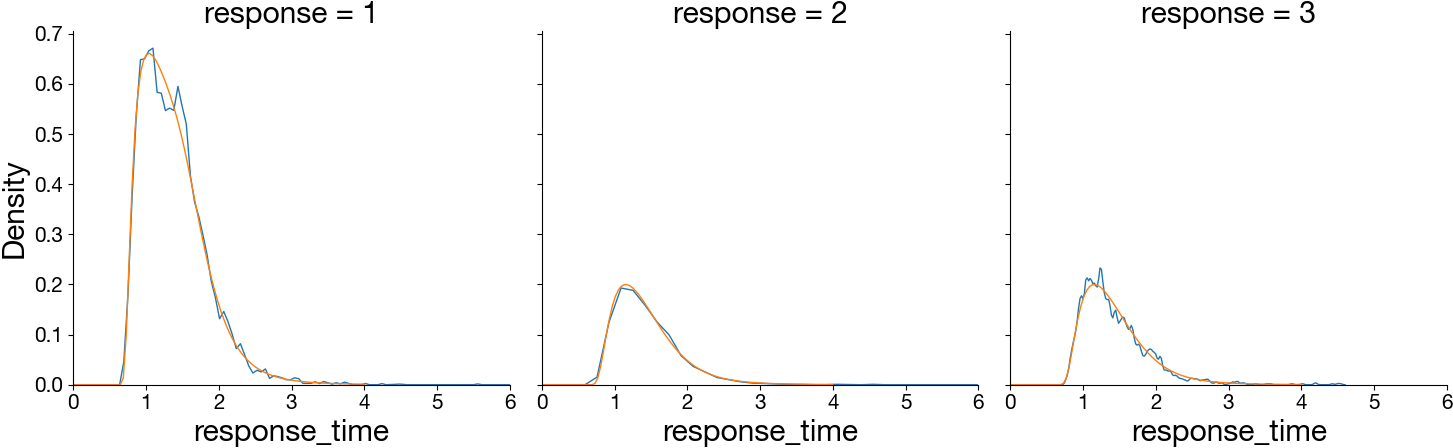

In [17]:
sim = pd.DataFrame({'response': response[:, 0], 'response_time': response[:, 1]})
g = sns.displot(
    data=sim,
    x='response_time',
    col='response',
    kind='kde',
    bw_adjust=.2,
    col_order=[1, 2, 3],
)
g.set(xlim=(0, 6))

sns.lineplot(
    data=sweep.query('response == 1'),
    x='response_time',
    y='pdf',
    color='C1',
    ax=g.axes[0, 0],
)
sns.lineplot(
    data=sweep.query('response == 2'),
    x='response_time',
    y='pdf',
    color='C1',
    ax=g.axes[0, 1]
)
sns.lineplot(
    data=sweep.query('response == 3'),
    x='response_time',
    y='pdf',
    color='C1',
    ax=g.axes[0, 2]
);